# 14 - Unsupervised Shapelets

**Problem framing.** Sometimes only a *small part* of each time series carries the signal - a brief spike, a characteristic dip - and it can appear at different times. Whole-series distances drown that local shape in the surrounding noise. A shapelet is a short subsequence that is maximally discriminative; an *unsupervised* shapelet (u-shapelet) is one whose distance to every series splits the dataset into a 'contains this pattern' group and a 'does not' group with a large gap - found with no labels.

**Assumptions.** The discriminating signal is a local subsequence of roughly known length; its position may vary; and z-normalised shape (not absolute level) is what matters.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

sys.path.append(str(Path.cwd() / "src"))

from unsup_lab.timeseries import discover_shapelets

## Dataset

Two hidden classes. Class 1 series contain a localised hump placed at a *random* position; class 0 series are pure noise. The position varies, so the discriminative pattern is local and phase-shifted - exactly what trips up whole-series comparisons. Labels are kept aside for offline checking only.

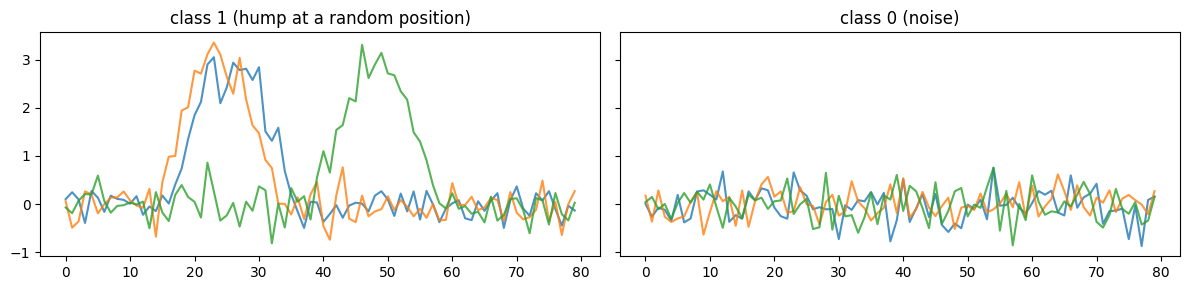

In [2]:
rng = np.random.default_rng(1)
length = 80
shapelet_len = 20
bump = np.sin(np.linspace(0, np.pi, shapelet_len)) * 3.0

series = []
labels = []
for _ in range(12):
    s = rng.normal(scale=0.3, size=length)
    start = int(rng.integers(0, length - shapelet_len))
    s[start : start + shapelet_len] += bump
    series.append(s)
    labels.append(1)
for _ in range(12):
    series.append(rng.normal(scale=0.3, size=length))
    labels.append(0)
labels = np.array(labels)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
for i in np.where(labels == 1)[0][:3]:
    ax1.plot(series[i], alpha=0.8)
ax1.set_title("class 1 (hump at a random position)")
for i in np.where(labels == 0)[0][:3]:
    ax2.plot(series[i], alpha=0.8)
ax2.set_title("class 0 (noise)")
plt.tight_layout()
plt.show()

## Discover the shapelet

`discover_shapelets` scans every candidate subsequence and keeps the one whose distance vector splits the dataset with the largest gap - without ever seeing the labels.

shapelet from series 10 at position 56
gap score: 2.942


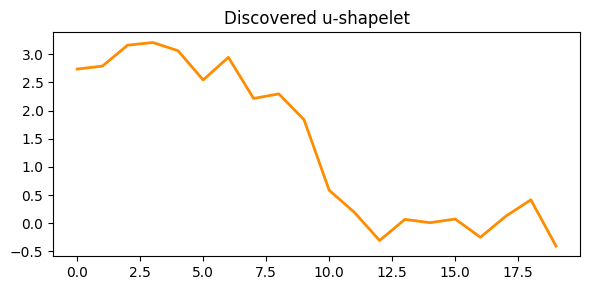

In [3]:
best = discover_shapelets(series, window=shapelet_len, n_shapelets=1, stride=4)[0]
print(f"shapelet from series {best.series_index} at position {best.start}")
print(f"gap score: {best.gap:.3f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(best.values, color="darkorange", lw=2)
ax.set_title("Discovered u-shapelet")
plt.tight_layout()
plt.show()

## Does the split recover the hidden classes?

The shapelet's distance to each series is bimodal: series that contain the hump sit near zero, the rest sit far away. The learned threshold separates them - and, checked offline, the split matches the hidden classes.

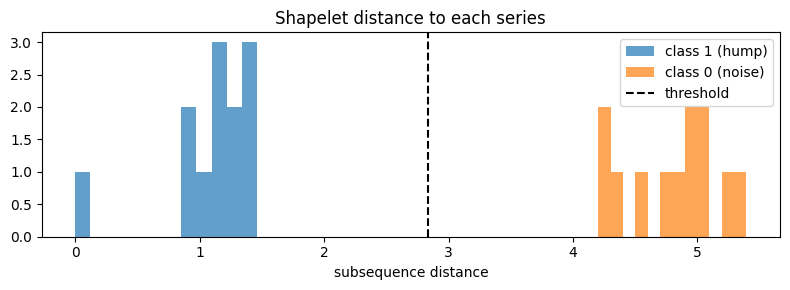

split ARI vs hidden classes: 1.000


In [4]:
predicted = (best.distances <= best.threshold).astype(int)
split_ari = max(
    adjusted_rand_score(labels, predicted),
    adjusted_rand_score(labels, 1 - predicted),
)

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(best.distances[labels == 1], bins=12, alpha=0.7, label="class 1 (hump)")
ax.hist(best.distances[labels == 0], bins=12, alpha=0.7, label="class 0 (noise)")
ax.axvline(best.threshold, color="black", linestyle="--", label="threshold")
ax.set_title("Shapelet distance to each series")
ax.set_xlabel("subsequence distance")
ax.legend()
plt.tight_layout()
plt.show()

print(f"split ARI vs hidden classes: {split_ari:.3f}")

## Baseline: whole-series clustering

The natural baseline runs KMeans on the raw series. Because the hump is local and lands at a different place each time, whole-series Euclidean distance cannot line the patterns up and the clustering largely fails.

In [5]:
whole_series = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(np.array(series))
baseline_ari = adjusted_rand_score(labels, whole_series)

print(f"u-shapelet split ARI : {split_ari:.3f}")
print(f"whole-series KMeans ARI: {baseline_ari:.3f}")

u-shapelet split ARI : 1.000
whole-series KMeans ARI: 0.225


## Interpretation and limitations

The u-shapelet finds the discriminative local pattern with no labels and separates the hidden classes cleanly, where whole-series clustering is defeated by the pattern's varying position. The shapelet is also *interpretable* - you can plot the exact shape that distinguishes the groups.

**Limitations.**

- Brute-force candidate search is expensive: O(candidates x series x window); the `stride` argument trades resolution for speed, and real use needs early-abandon and pruning.
- The shapelet length is a real choice; a length far from the true pattern scale weakens the gap.
- The gap score assumes one substantial subgroup carries the pattern; finely balanced or multi-pattern data needs several shapelets.
- Z-normalisation ignores amplitude, so a pattern that differs only in scale will not be found.